# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('california_dataset.csv')

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


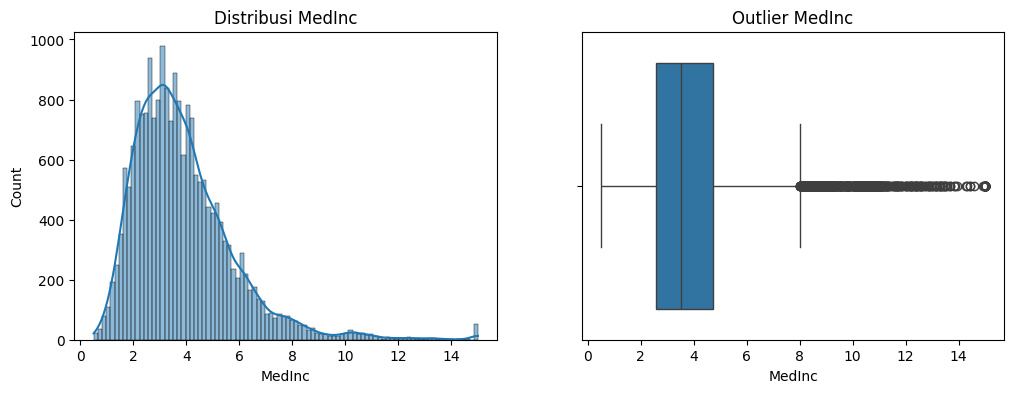

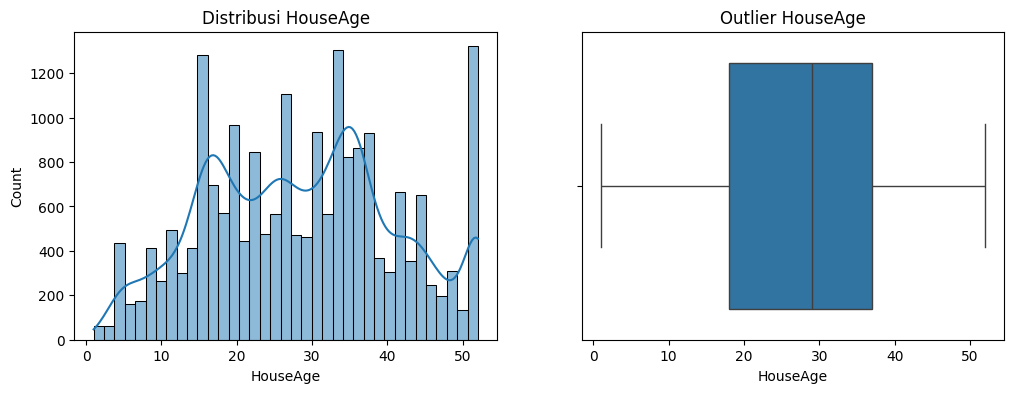

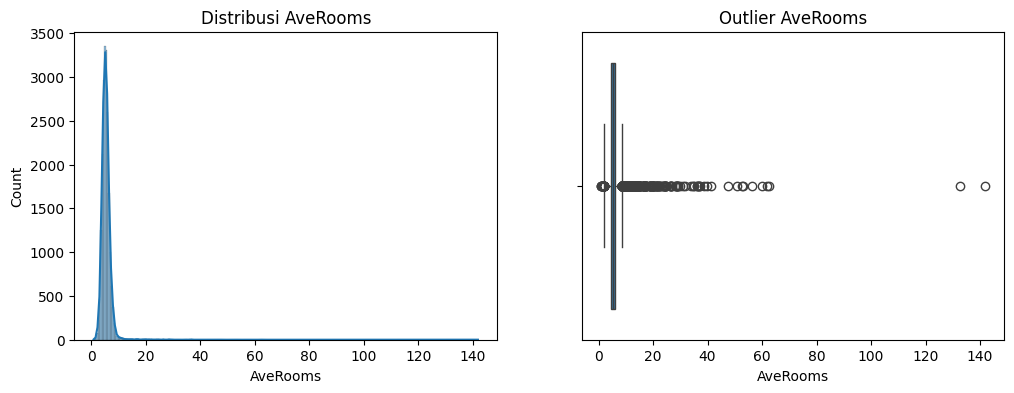

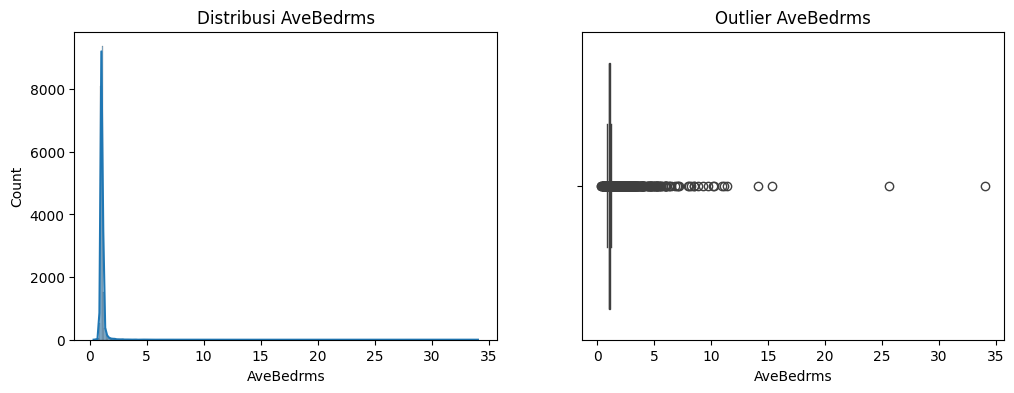

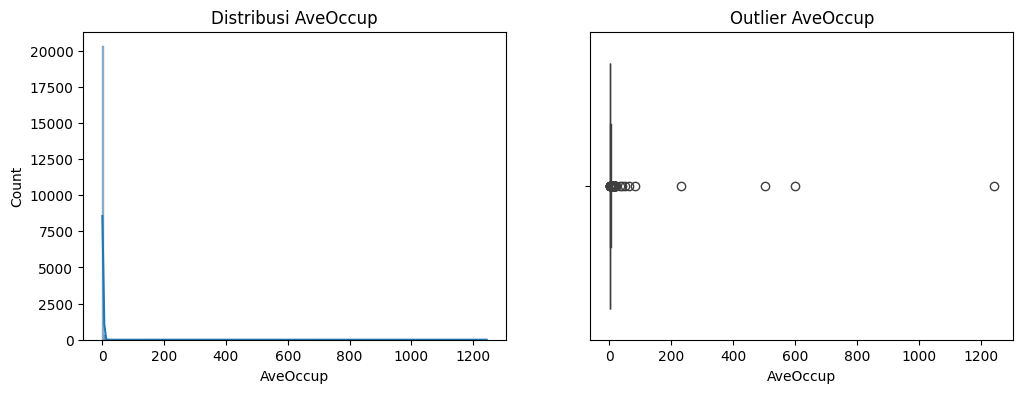

In [18]:
# Daftar nama kolom yang ingin Anda cek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Loop untuk melihat distribusi dan outlier
for kolom in kolom_kolom:
    
    plt.figure(figsize=(12,4))
    
    # Plot distribusi
    plt.subplot(1,2,1)
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom}')
    
    # Plot outlier
    plt.subplot(1,2,2)
    sns.boxplot(x=df[kolom])
    plt.title(f'Outlier {kolom}')
    
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [26]:
# Pilih 1 kolom untuk handling outlier
kolom = 'MedInc'

# Hitung Q1, Q3 dan IQR
Q1 = df[kolom].quantile(0.25)
Q3 = df[kolom].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Menghapus outlier
df_no_outlier = df[(df[kolom] >= lower) & (df[kolom] <= upper)]

print("Jumlah data sebelum:", df.shape)
print("Jumlah data sesudah:", df_no_outlier.shape)

Jumlah data sebelum: (20640, 9)
Jumlah data sesudah: (19959, 9)


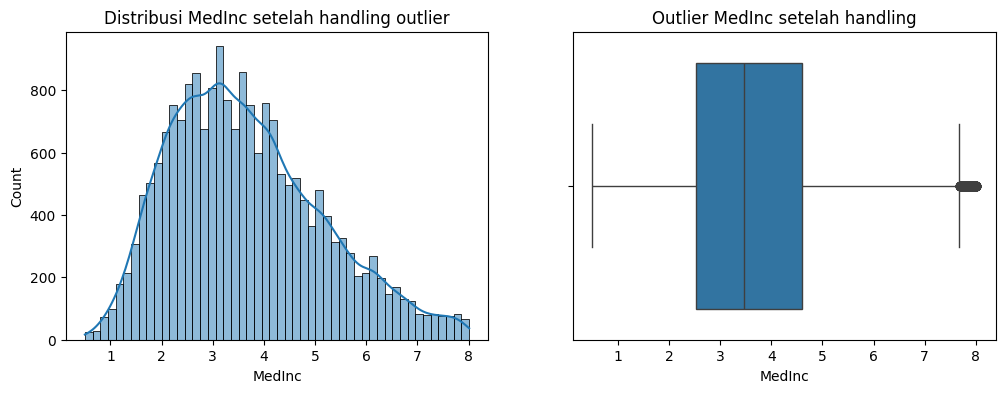

In [24]:
# Cek distribusi setelah handling outlier

plt.figure(figsize=(12,4))

# Distribusi
plt.subplot(1,2,1)
sns.histplot(df_no_outlier[kolom], kde=True)
plt.title(f'Distribusi {kolom} setelah handling outlier')

plt.subplot(1,2,2)
sns.boxplot(x=df_no_outlier[kolom])
plt.title(f'Outlier {kolom} setelah handling')

plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [27]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [28]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [32]:
# Cek missing value pada kolom Headquarters

import pandas as pd

# Load dataset
df_company = pd.read_csv('company.csv')

# Hitung jumlah missing value
missing = df_company['Headquarters'].isnull().sum()

# Hitung persentase missing value
persentase = (missing / len(df_company)) * 100

print("Jumlah missing value:", missing)
print("Persentase missing value:", persentase, "%")

# Cek apakah perlu drop kolom
if persentase > 20:
    print("Missing value > 20% → Kolom sebaiknya di-drop")
else:
    print("Missing value <= 20% → Kolom tidak perlu di-drop")

    modus = df_company['Headquarters'].mode()[0]
    df_company['Headquarters'].fillna(modus, inplace=True)

    print("Missing value sudah diisi dengan modus:", modus)

Jumlah missing value: 0
Persentase missing value: 0.0 %
Missing value <= 20% → Kolom tidak perlu di-drop
Missing value sudah diisi dengan modus: New York, NY


C:\Users\HP 14\AppData\Local\Temp\ipykernel_19392\3564424822.py:24: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_company['Headquarters'].fillna(modus, inplace=True)


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [39]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [42]:
#Splitting terlebih dahulu


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [41]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# Daftar kolom yang akan di-encode
kolom = ['StreamingMovies', 'StreamingTV', 'TechSupport',
         'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# Mengganti nilai "No internet service" menjadi "No"
for k in kolom:
    df_churn[k] = df_churn[k].replace('No internet service', 'No')

# Validasi dengan value_counts
for k in kolom:
    print("Value counts untuk", k)
    print(df_churn[k].value_counts())
    print()

# Label Encoding
le = LabelEncoder()

for k in kolom:
    df_churn[k] = le.fit_transform(df_churn[k])

# Cek hasil encoding
df_churn[kolom].head()

Value counts untuk StreamingMovies
StreamingMovies
0    4311
1    2732
Name: count, dtype: int64

Value counts untuk StreamingTV
StreamingTV
0    4336
1    2707
Name: count, dtype: int64

Value counts untuk TechSupport
TechSupport
0    4999
1    2044
Name: count, dtype: int64

Value counts untuk DeviceProtection
DeviceProtection
0    4621
1    2422
Name: count, dtype: int64

Value counts untuk OnlineBackup
OnlineBackup
0    4614
1    2429
Name: count, dtype: int64

Value counts untuk OnlineSecurity
OnlineSecurity
0    5024
1    2019
Name: count, dtype: int64

Value counts untuk MultipleLines
MultipleLines
0    3390
2    2971
1     682
Name: count, dtype: int64



,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,0,0,0,0,1,0,1
1,0,0,0,1,0,1,0
2,0,0,0,0,1,1,0
3,0,0,1,1,0,1,1
4,0,0,0,0,0,0,0


## Selesai :)